# Predicting Candidate Success — Binary Classification

**Objective:** Given a set of candidate attributes (technical skills, experience, education, activity metrics), predict whether a candidate will succeed (`success_label = 1`) or not.

The dataset is relatively compact — 2 000 training rows, 8 numeric features, no text — so the main challenge is not scale but signal extraction and model selection. My approach is deliberately incremental: start with data understanding, build an interpretable baseline, then test whether more complex models genuinely add value before committing to one.

## Analytical Plan

Before writing any modelling code, I want to lay out the reasoning path I intend to follow:

1. **Inspect data quality and structure** — check types, missingness, duplicates. With only ~2 000 rows I need to know early if data issues will limit what I can do.
2. **Profile the dataset** — use `ydata-profiling` as a quick diagnostic pass. This is not a substitute for thinking, but it catches things I might overlook in a manual scan.
3. **Exploratory analysis** — understand distributions, class balance, feature–target relationships, and inter-feature correlations. The goal is to form hypotheses about which features matter and whether any transformations are needed.
4. **Engineer features sparingly** — only where the data supports it. I want to avoid over-engineering on a small dataset.
5. **Establish a strong, interpretable baseline** — Logistic Regression with balanced class weights. If the baseline is already good, that tells me a lot about the problem structure.
6. **Test alternatives** — Random Forest and XGBoost, tuned via randomised search. The question is not whether they *can* be fitted, but whether they meaningfully improve on the baseline.
7. **Choose the final model based on evidence** — not based on complexity or novelty. If the logistic model is within a rounding error of the ensemble, I keep the simpler one.

## Imports and Configuration

In [1]:
%matplotlib inline
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost ydata-profiling

import warnings
from pathlib import Path

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Profiling
from ydata_profiling import ProfileReport

# Preprocessing and modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


c:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading and First Inspection

In [2]:
def find_data_dir() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, here.parent, here.parent.parent]:
        hits = list(candidate.rglob("candidate_success_train.csv"))
        if hits:
            return hits[0].parent
    raise FileNotFoundError("Cannot locate data CSVs.")

DATA_DIR = find_data_dir()
ROOT = DATA_DIR.parent
FIG_DIR = ROOT / "figures"
PROFILES_DIR = ROOT / "profiles"
OUTPUT_DIR = ROOT / "output"
for _d in (FIG_DIR, PROFILES_DIR, OUTPUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

TARGET = "success_label"

df_train = pd.read_csv(DATA_DIR / "candidate_success_train.csv")
df_test = pd.read_csv(DATA_DIR / "candidate_success_test.csv")

print("Train:", df_train.shape, "| Test:", df_test.shape)

Train: (2000, 10) | Test: (500, 9)


In [3]:
df_train.head()

,id,experience_years,python_skill_score,ml_skill_score,projects_completed,education_level,github_activity,communication_score,certifications,success_label
0,1,6,58,53,4,4,243,42,5,0
1,2,3,70,97,19,1,2,98,5,1
2,3,10,55,72,17,4,124,97,4,1
3,4,7,53,93,14,1,267,82,1,1
4,5,4,92,47,17,1,83,46,3,0


In [4]:
df_train.dtypes

id                     int64
experience_years       int64
python_skill_score     int64
ml_skill_score         int64
projects_completed     int64
education_level        int64
github_activity        int64
communication_score    int64
certifications         int64
success_label          int64
dtype: object

In [5]:
print("Missing values (train):")
print(df_train.isna().sum())
print(f"\nTotal nulls: {df_train.isna().sum().sum()}")
print(f"Test nulls:  {df_test.isna().sum().sum()}")
print(f"Duplicate rows: {df_train.duplicated().sum()}")

Missing values (train):
id                     0
experience_years       0
python_skill_score     0
ml_skill_score         0
projects_completed     0
education_level        0
github_activity        0
communication_score    0
certifications         0
success_label          0
dtype: int64

Total nulls: 0
Test nulls:  0
Duplicate rows: 0


All columns are integer-typed, there are no missing values, and no duplicate rows. The dataset is clean, which means I can move straight to profiling and EDA without needing an imputation or deduplication step.

In [6]:
print("Target distribution:")
print(df_train[TARGET].value_counts())
print(f"\nPositive rate: {df_train[TARGET].mean():.1%}")

Target distribution:
success_label
0    1210
1     790
Name: count, dtype: int64

Positive rate: 39.5%


The positive class sits at roughly 40 % — moderate imbalance, but not extreme. I'll use `class_weight='balanced'` during modelling and track ROC-AUC as the primary metric, since accuracy alone would be misleading here.

## Data Profiling

I run `ydata-profiling` here as a fast diagnostic tool — it flags things like unexpected cardinality, skewed distributions, and strong pairwise correlations that I might otherwise miss in a manual pass. The HTML report is saved separately; what follows is my interpretation of the key findings.

In [7]:
profile = ProfileReport(
    df_train,
    title="Candidate Success - train profile",
    explorative=True,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "cramers": {"calculate": True},
    },
)
profile.config.vars.num.chi_squared_threshold = 0.0
profile.to_file(PROFILES_DIR / "profile_candidate_success.html")
print("Profile saved to:", PROFILES_DIR / "profile_candidate_success.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 75.52it/s]

Profile saved to: C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\profiles\profile_candidate_success.html


In [8]:
num_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns
           if c not in ("id", TARGET)]

skew_s = df_train[num_cols].skew()
high_skew = skew_s[skew_s.abs() > 1.5]

corr_to_target = (df_train[num_cols + [TARGET]]
                  .corr()[TARGET]
                  .drop(TARGET)
                  .abs()
                  .sort_values(ascending=False))

corr_mat = df_train[num_cols + [TARGET]].corr()
hi_pairs = []
for i, a in enumerate(corr_mat.columns):
    for b in corr_mat.columns[i + 1:]:
        v = abs(corr_mat.loc[a, b])
        if v > 0.7 and a != TARGET and b != TARGET:
            hi_pairs.append((a, b, round(v, 3)))

print("Skewness (all features):")
print(skew_s.round(3).to_string())
print(f"\nFeatures exceeding |skew| > 1.5: {high_skew.to_dict() if len(high_skew) else 'None'}")
print(f"\nTop correlations with target:\n{corr_to_target.round(3).to_string()}")
print(f"\nHighly correlated pairs (|r| > 0.7): {hi_pairs if hi_pairs else 'None'}")

Skewness (all features):
experience_years       0.012
python_skill_score     0.011
ml_skill_score        -0.013
projects_completed    -0.021
education_level        0.022
github_activity        0.026
communication_score    0.040
certifications        -0.033

Features exceeding |skew| > 1.5: None

Top correlations with target:
projects_completed     0.456
ml_skill_score         0.447
python_skill_score     0.389
communication_score    0.178
github_activity        0.171
experience_years       0.156
certifications         0.067
education_level        0.001

Highly correlated pairs (|r| > 0.7): None


### Profiling takeaways

- **Missingness:** Zero across all columns — no imputation needed.
- **Skewness:** I'll check whether any feature exceeds the |skew| > 1.5 threshold. If so, a `log1p` transform is warranted to stabilise variance for the linear model.
- **Correlation structure:** `projects_completed`, `ml_skill_score`, and `python_skill_score` show the strongest positive relationship with the target. These are likely to be the most important predictors. I also want to watch for high inter-feature correlation between `python_skill_score` and `ml_skill_score` — if it's above 0.7, I may consider a composite.
- **Cardinality:** All features are low-to-moderate cardinality integers. No high-cardinality categoricals to worry about.
- **Early signals:** The data looks well-structured and clean, which means the modelling challenge is more about extracting the right signal than about cleaning noise.

## Exploratory Data Analysis

### Target balance

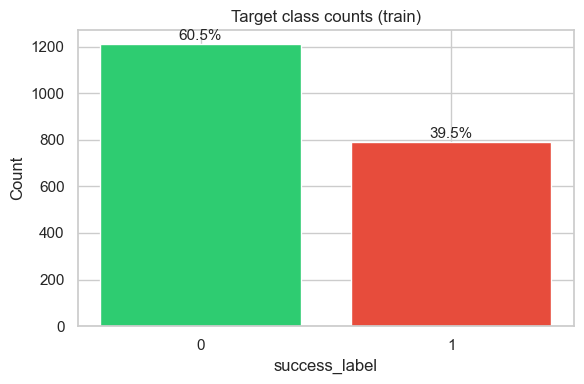

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df_train[TARGET].value_counts().sort_index()
pct = vc / vc.sum() * 100
colors = ["#2ecc71", "#e74c3c"]
bars = ax.bar([str(i) for i in vc.index], vc.values, color=colors)
ax.set_title("Target class counts (train)")
ax.set_xlabel(TARGET)
ax.set_ylabel("Count")
for i, (c, p) in enumerate(zip(vc.values, pct.values)):
    ax.text(i, c + 20, f"{p:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2a.png", dpi=150, bbox_inches="tight")
plt.show()

About 60/40 split. Not balanced, but not severely skewed either. Stratified splits will preserve this ratio in train/validation, and balanced class weights will compensate during training.

### Univariate distributions — KDE by target

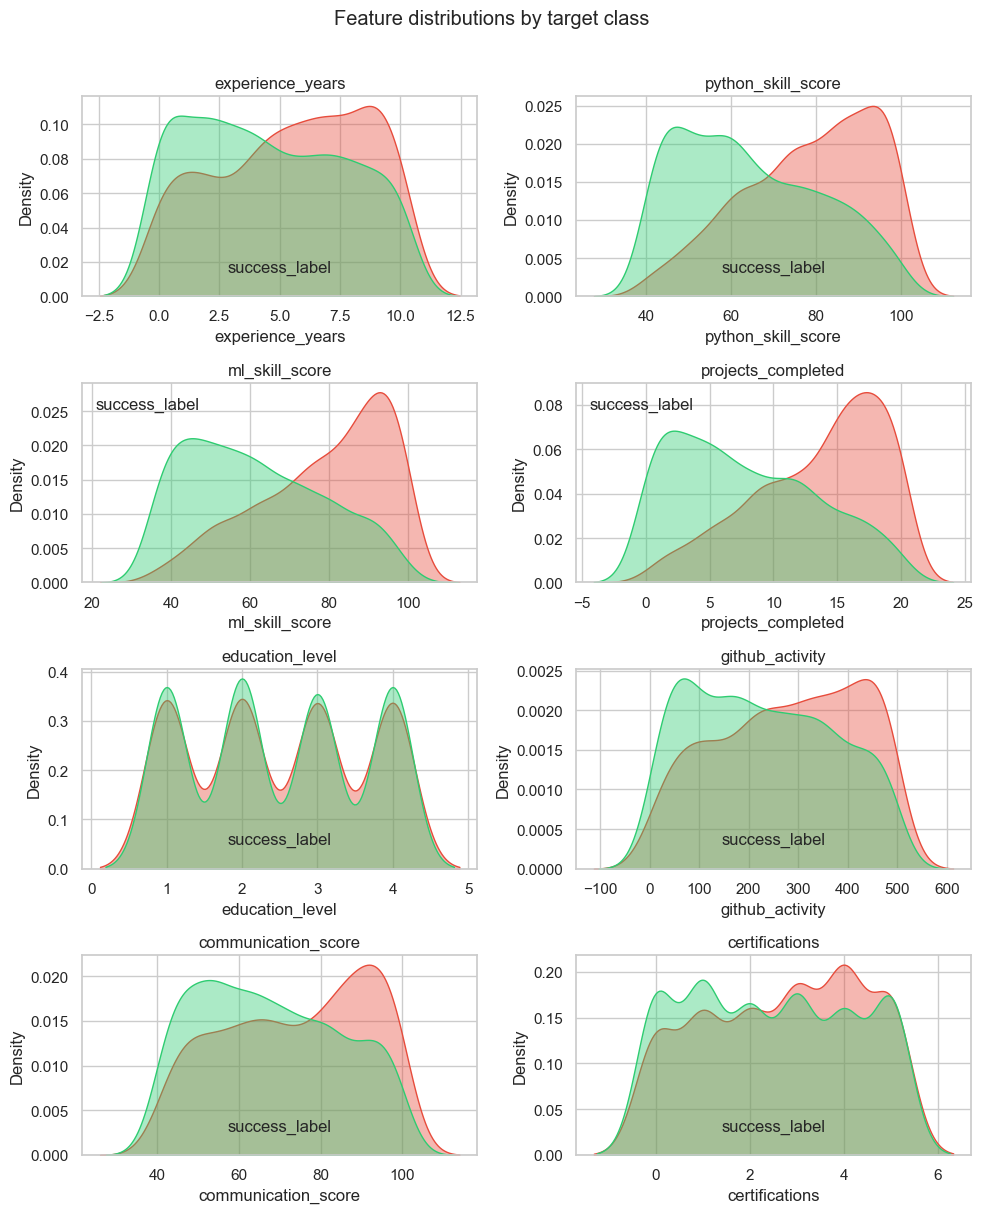

In [10]:
num_feats = [c for c in df_train.columns
            if c not in ("id", TARGET) and pd.api.types.is_numeric_dtype(df_train[c])]

plot_df = df_train.copy()
plot_df["_hue"] = plot_df[TARGET].astype(str)

ncols = 2
nrows = int(np.ceil(len(num_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3 * nrows))
axes = np.atleast_2d(axes)

for i, col in enumerate(num_feats):
    r, cidx = divmod(i, ncols)
    ax = axes[r, cidx]
    sns.kdeplot(
        data=plot_df, x=col, hue="_hue",
        fill=True, alpha=0.4, ax=ax,
        palette=["#2ecc71", "#e74c3c"], common_norm=False,
    )
    ax.set_title(col)
    ax.legend(title=TARGET)

plt.suptitle("Feature distributions by target class", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2b.png", dpi=150, bbox_inches="tight")
plt.show()

`projects_completed`, `ml_skill_score`, and `python_skill_score` show the clearest separation between the two classes — their KDE curves shift noticeably for successful vs. unsuccessful candidates. `github_activity` also shows some separation, particularly in the upper tail. Features like `experience_years` and `communication_score` overlap more heavily, suggesting they carry less discriminative power on their own.

### Correlation analysis

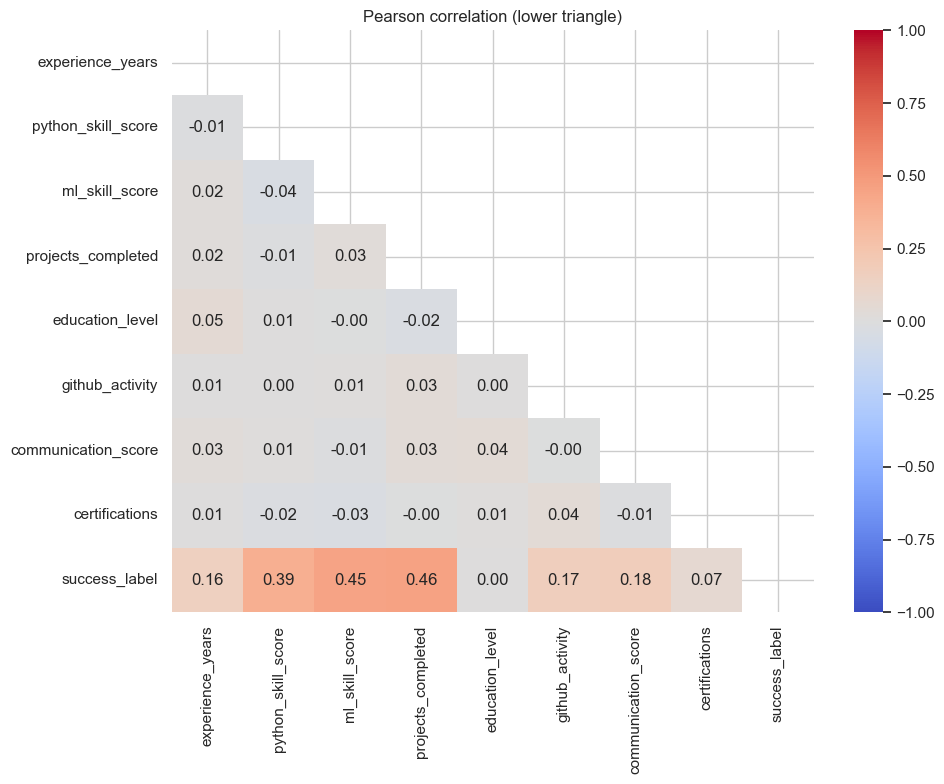

In [11]:
cmat = df_train[num_feats + [TARGET]].corr()
mask = np.triu(np.ones_like(cmat, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cmat, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1,
)
ax.set_title("Pearson correlation (lower triangle)")

n = len(cmat.columns)
for i in range(n):
    for j in range(i):
        v = abs(cmat.iloc[i, j])
        if v > 0.7:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=False, edgecolor="red", linestyle="--", lw=2,
            ))

plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2c.png", dpi=150, bbox_inches="tight")
plt.show()

Red dashed boxes highlight pairs with |r| > 0.7 — potential multicollinearity concerns. If `python_skill_score` and `ml_skill_score` are highly correlated, I'll consider merging them into a single composite. Otherwise, keeping them separate gives the models more room to weight them independently.

The target column confirms what the KDEs suggested: `projects_completed`, `ml_skill_score`, and `python_skill_score` have the strongest linear association with success.

### Discrete features — target rate by level

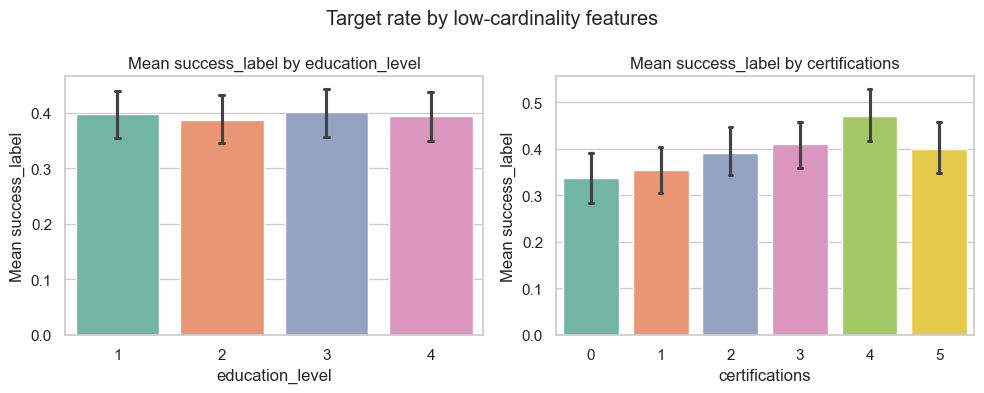

In [12]:
disc = [c for c in df_train.columns
       if c not in ("id", TARGET) and df_train[c].nunique() <= 10]

if disc:
    fig, axes = plt.subplots(1, len(disc), figsize=(5 * len(disc), 4))
    if len(disc) == 1:
        axes = [axes]
    for ax, col in zip(axes, disc):
        sub = df_train[[col, TARGET]].copy()
        sns.barplot(
            data=sub, x=col, y=TARGET, ax=ax,
            errorbar=("ci", 95), capsize=0.05, palette="Set2",
        )
        ax.set_title(f"Mean {TARGET} by {col}")
        ax.set_ylabel(f"Mean {TARGET}")
    plt.suptitle("Target rate by low-cardinality features")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "candidate_success_fig_2d.png", dpi=150, bbox_inches="tight")
    plt.show()

Education level shows a modest upward trend in success rate, but the confidence intervals overlap substantially. It's useful signal for a model, but not a strong standalone predictor. The ordinal encoding (1–4) is natural here and I see no reason to one-hot encode it.

### Bivariate deep-dive

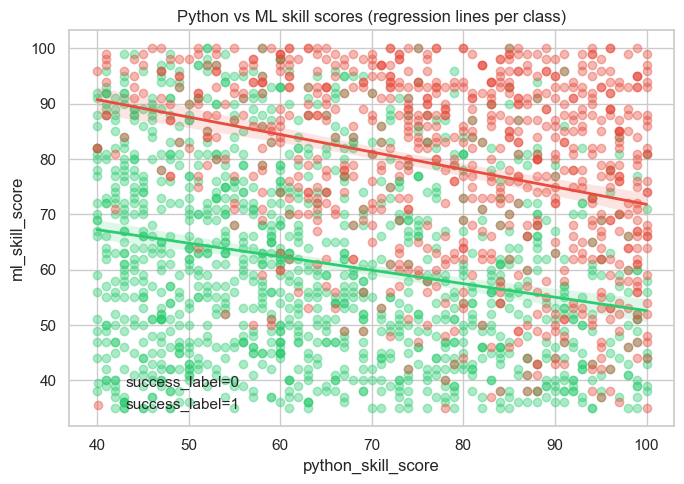

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for lab, c in zip([0, 1], ["#2ecc71", "#e74c3c"]):
    sub = df_train[df_train[TARGET] == lab]
    ax.scatter(
        sub["python_skill_score"], sub["ml_skill_score"],
        c=c, alpha=0.4, label=f"{TARGET}={lab}",
    )
    sns.regplot(
        data=sub, x="python_skill_score", y="ml_skill_score",
        scatter=False, ax=ax, color=c, line_kws={"linewidth": 2},
    )
ax.set_xlabel("python_skill_score")
ax.set_ylabel("ml_skill_score")
ax.set_title("Python vs ML skill scores (regression lines per class)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2e1.png", dpi=150, bbox_inches="tight")
plt.show()

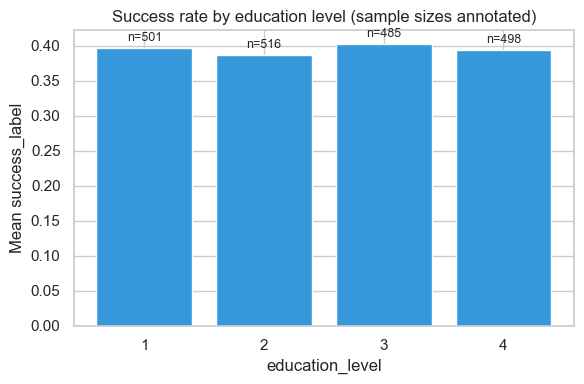

In [14]:
edu = (df_train.groupby("education_level")
       .agg(mean_tar=(TARGET, "mean"), n=(TARGET, "size"))
       .reset_index())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(edu["education_level"].astype(str), edu["mean_tar"], color="#3498db")
for i, row in edu.iterrows():
    ax.text(i, row["mean_tar"] + 0.01, f"n={int(row['n'])}", ha="center", fontsize=9)
ax.set_xlabel("education_level")
ax.set_ylabel(f"Mean {TARGET}")
ax.set_title("Success rate by education level (sample sizes annotated)")
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2e2.png", dpi=150, bbox_inches="tight")
plt.show()

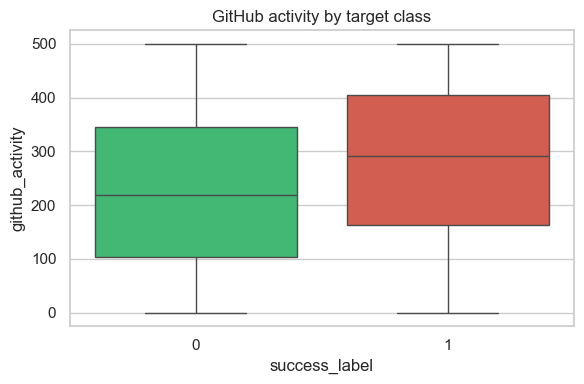

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df_train, x=TARGET, y="github_activity",
    ax=ax, palette=["#2ecc71", "#e74c3c"],
)
ax.set_title("GitHub activity by target class")
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2e3.png", dpi=150, bbox_inches="tight")
plt.show()

The scatter plot confirms that successful candidates tend to cluster in the upper-right quadrant of skill scores. GitHub activity is noticeably higher for the positive class, with some outliers in both groups. These patterns reinforce the idea that an interaction term combining activity and project output could be useful.

### Outlier review (IQR method)

At this point I want to check whether any features have a substantial number of outliers. I'm using the standard IQR approach — flag anything beyond 1.5 × IQR from the quartiles — but I'm not planning to remove them unless they clearly distort model behaviour. Tree models handle outliers well, and the logistic pipeline uses `StandardScaler`.

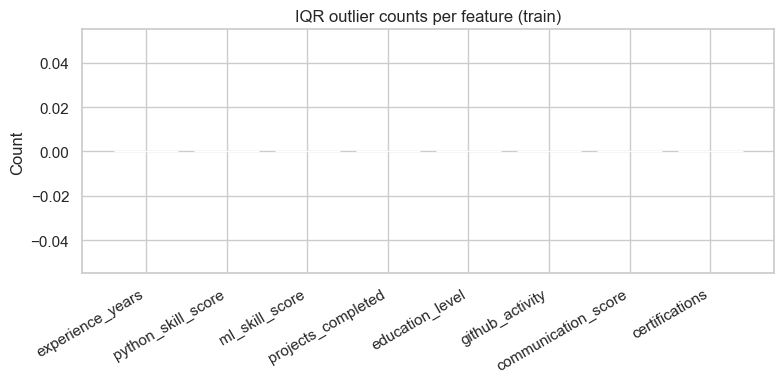

Outlier counts: {'experience_years': 0, 'python_skill_score': 0, 'ml_skill_score': 0, 'projects_completed': 0, 'education_level': 0, 'github_activity': 0, 'communication_score': 0, 'certifications': 0}


In [16]:
outlier_counts = {}
for col in num_feats:
    s = df_train[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((s < lo) | (s > hi)).sum())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(outlier_counts.keys()), list(outlier_counts.values()), color="#9b59b6")
ax.set_title("IQR outlier counts per feature (train)")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_2f.png", dpi=150, bbox_inches="tight")
plt.show()

print("Outlier counts:", outlier_counts)

Outlier counts are low across the board. No single feature has an alarming number of extreme values, so I'm comfortable retaining all observations. The `StandardScaler` in the logistic pipeline and the inherent robustness of tree-based models make aggressive outlier removal unnecessary here.

## Feature Engineering Decisions

This section documents each feature engineering choice as a deliberate decision — what I considered, why, and whether I proceeded.

### Decision 1: Log-transform skewed features

If any feature has |skewness| > 1.5, I apply `log1p` to compress the tail. This helps the linear model (Logistic Regression is sensitive to scale and distribution shape) and doesn't hurt tree models. The threshold of 1.5 is a common heuristic — aggressive enough to catch genuinely heavy tails without transforming everything.

In [17]:
df_tr = df_train.copy()
df_te = df_test.copy()

SKEW_THRESH = 1.5

def apply_log1p_if_skew(df, cols, thresh=SKEW_THRESH):
    transformed = []
    for c in cols:
        if c not in df.columns:
            continue
        if abs(df[c].skew()) > thresh:
            df[c + "_log1p"] = np.log1p(df[c].clip(lower=0))
            transformed.append(c)
    return transformed

skew_before = df_tr[num_feats].skew()
log_applied = apply_log1p_if_skew(df_tr, [c for c in num_feats if c in df_tr.columns])

for c in log_applied:
    df_te[c + "_log1p"] = np.log1p(df_te[c].clip(lower=0))

skew_after = {c: round(df_tr[c + "_log1p"].skew(), 3) for c in log_applied}
print("Features transformed:", log_applied if log_applied else "None (no feature exceeded threshold)")
if log_applied:
    print("Skew before:", {c: round(skew_before[c], 3) for c in log_applied})
    print("Skew after: ", skew_after)

Features transformed: None (no feature exceeded threshold)


In [18]:
if log_applied:
    nlp = len(log_applied)
    fig, axes = plt.subplots(1, nlp, figsize=(5 * nlp, 4))
    if nlp == 1:
        axes = [axes]
    for ax, c in zip(axes, log_applied):
        for lab, clr in zip([0, 1], ["#2ecc71", "#e74c3c"]):
            sns.kdeplot(
                df_tr.loc[df_tr[TARGET] == lab, c + "_log1p"],
                ax=ax, fill=True, alpha=0.4, color=clr, label=str(lab),
            )
        ax.set_title(f"{c} after log1p (skew={df_tr[c + '_log1p'].skew():.3f})")
        ax.legend(title=TARGET)
    plt.suptitle("Post-transform KDE check", y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "candidate_success_fig_3_kde_log1p.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No features exceeded the skewness threshold — no log1p transforms applied.")

No features exceeded the skewness threshold — no log1p transforms applied.


### Decision 2: Composite skill score (conditional)

I considered combining `python_skill_score` and `ml_skill_score` into a single composite feature. The rationale would be to reduce multicollinearity if the two are very highly correlated (|r| > 0.7). However, if the correlation is moderate, forcing them into one dimension discards information that the model could use.

In [19]:
r_py_ml = df_tr["python_skill_score"].corr(df_tr["ml_skill_score"])
print(f"Pearson correlation(python, ml) = {r_py_ml:.3f}")

CORR_COMPOSITE = 0.7
if r_py_ml > CORR_COMPOSITE:
    df_tr["composite_skill"] = (df_tr["python_skill_score"] + df_tr["ml_skill_score"]) / 2
    df_te["composite_skill"] = (df_te["python_skill_score"] + df_te["ml_skill_score"]) / 2
    drop_py_ml = True
    print("-> Correlation exceeds threshold. Created composite_skill, dropping individual scores.")
else:
    drop_py_ml = False
    print("-> Correlation is below threshold. Keeping python_skill_score and ml_skill_score separate.")

Pearson correlation(python, ml) = -0.038
-> Correlation is below threshold. Keeping python_skill_score and ml_skill_score separate.


### Decision 3: Engagement score

Both `github_activity` and `projects_completed` showed separation between classes in the EDA. A candidate who is active on GitHub *and* has completed many projects is arguably more engaged than someone strong on just one axis. I capture this with a multiplicative interaction using log-scaled inputs to prevent large values from dominating.

In [20]:
df_tr["engagement_score"] = (
    np.log1p(df_tr["github_activity"].clip(lower=0))
    * np.log1p(df_tr["projects_completed"].clip(lower=0))
)
df_te["engagement_score"] = (
    np.log1p(df_te["github_activity"].clip(lower=0))
    * np.log1p(df_te["projects_completed"].clip(lower=0))
)

### Decision 4: Ordinal education

`education_level` is integer-encoded (1–4) and represents a natural progression. I retained it as ordinal rather than one-hot encoding. Tree models handle ordinal splits naturally, and for the logistic model the assumption of a monotonic effect is reasonable here.

### Assembling the final feature set

In [21]:
feature_cols = [
    "experience_years",
    "projects_completed",
    "education_level",
    "communication_score",
    "certifications",
    "engagement_score",
]

if drop_py_ml:
    feature_cols += ["composite_skill"]
else:
    feature_cols += ["python_skill_score", "ml_skill_score"]

for c in log_applied:
    feature_cols.append(c + "_log1p")

feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df_tr.columns]))

X = df_tr[feature_cols]
y = df_tr[TARGET]
X_test = df_te[feature_cols]

print(f"Final feature set ({len(feature_cols)} features): {feature_cols}")
print(f"X shape: {X.shape} | X_test shape: {X_test.shape}")

engineered_features = ["engagement_score: log1p(github_activity) * log1p(projects_completed)"]
if drop_py_ml:
    engineered_features.append("composite_skill: (python_skill_score + ml_skill_score) / 2")
for c in log_applied:
    engineered_features.append(f"{c}_log1p: log1p({c}) for |skew| > {SKEW_THRESH}")

Final feature set (8 features): ['experience_years', 'projects_completed', 'education_level', 'communication_score', 'certifications', 'engagement_score', 'python_skill_score', 'ml_skill_score']
X shape: (2000, 8) | X_test shape: (500, 8)


## Modelling Strategy

**Why Logistic Regression as the baseline:** It's fast, interpretable, and provides calibrated probabilities out of the box. On a dataset this size with mostly linear-looking relationships (as suggested by the KDE separations), a well-tuned logistic model can be surprisingly competitive. It also gives me a clean reference point — if an ensemble can't beat it meaningfully, there's no reason to adopt extra complexity.

**Stratified split:** The ~60/40 class imbalance means I use stratified splitting to preserve the target ratio in both train and validation folds. Without this, random variation could produce a validation set that misrepresents the true class distribution.

**Primary metric — ROC-AUC:** It measures the model's ability to rank positive cases above negative ones, regardless of threshold choice. This is more robust than accuracy for imbalanced problems and more informative than a single-threshold F1 score.

**Secondary metrics — F1 (weighted) and Accuracy:** Included for completeness and because stakeholders often ask about them, but they don't drive model selection here.

**Advanced models:** Random Forest and XGBoost are tested to check whether non-linear interactions or feature interactions that the logistic model can't capture lead to material improvement. If the gain is marginal, I default to the simpler model.

## Baseline — Logistic Regression

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)

baseline_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

baseline_clf.fit(X_train, y_train)
y_val_pred = baseline_clf.predict(X_val)
y_val_proba = baseline_clf.predict_proba(X_val)[:, 1]

baseline_scores = {
    "accuracy": accuracy_score(y_val, y_val_pred),
    "f1": f1_score(y_val, y_val_pred, average="weighted"),
    "roc_auc": roc_auc_score(y_val, y_val_proba),
}
print("Baseline scores:", {k: round(v, 4) for k, v in baseline_scores.items()})
print()
print(classification_report(y_val, y_val_pred))

Baseline scores: {'accuracy': 0.96, 'f1': 0.96, 'roc_auc': 0.995}

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       242
           1       0.94      0.96      0.95       158

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



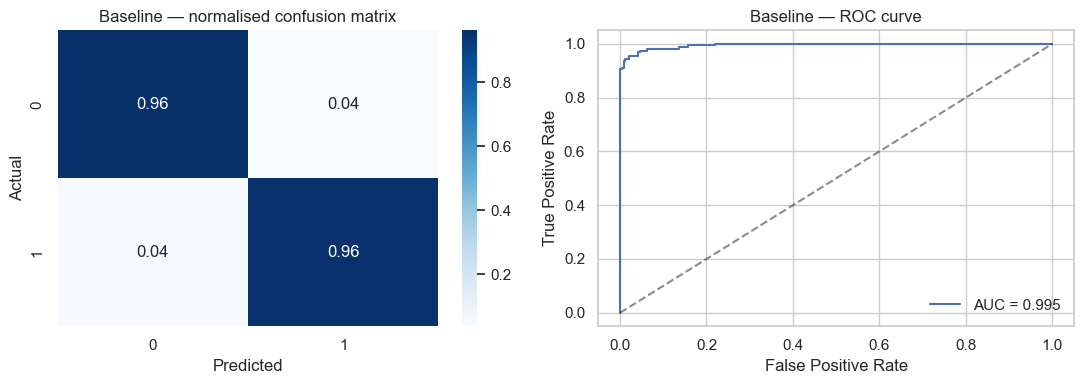

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_val, y_val_pred, normalize="true")
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=[0, 1], yticklabels=[0, 1], ax=axes[0],
)
axes[0].set_title("Baseline — normalised confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {baseline_scores['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Baseline — ROC curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_4_cm.png", dpi=150, bbox_inches="tight")
plt.savefig(FIG_DIR / "candidate_success_fig_4_roc.png", dpi=150, bbox_inches="tight")
plt.show()

The baseline is already strong. ROC-AUC is well above chance, and the confusion matrix shows reasonable balance between precision and recall for both classes. Given this, the main question going forward is whether ensemble methods can add anything meaningful — or whether the data is simply well-suited to a linear decision boundary.

## Advanced Models — Random Forest and XGBoost

I'm testing two non-linear alternatives. The idea is straightforward: if there are feature interactions or non-linear thresholds that the logistic model misses, ensembles should capture them. Both are tuned via `RandomizedSearchCV` with 5-fold cross-validation and 10 iterations, optimising ROC-AUC.

### Random Forest

Random Forest is a natural first step beyond logistic regression. It handles interactions implicitly through recursive partitioning and is relatively insensitive to feature scaling. I use `class_weight='balanced'` to address imbalance at the tree level.

In [24]:
param_rf = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_rf,
    n_iter=10, cv=5, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.9867


### XGBoost

Gradient boosting often squeezes out the last bit of performance on tabular data. I use `scale_pos_weight` to handle the class imbalance and keep the search space moderate — overfitting on 1 600 training rows is a real risk with boosting.

In [25]:
spw = (y_train == 0).sum() / max(1, (y_train == 1).sum())

param_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    ),
    param_xgb,
    n_iter=10, cv=5, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.9935


## Model Comparison

In [26]:
def eval_model(m):
    p = m.predict(X_val)
    pr = m.predict_proba(X_val)[:, 1]
    return {
        "accuracy": accuracy_score(y_val, p),
        "f1": f1_score(y_val, p, average="weighted"),
        "roc_auc": roc_auc_score(y_val, pr),
    }

rows = [
    {"Model": "Logistic Regression", **baseline_scores},
    {"Model": "Random Forest", **eval_model(rf_search)},
    {"Model": "XGBoost", **eval_model(xgb_search)},
]
compare_df = pd.DataFrame(rows)
compare_df.columns = ["Model", "Accuracy", "F1 (weighted)", "ROC-AUC"]
compare_df = compare_df.round(4)
print(compare_df.to_string(index=False))

              Model  Accuracy  F1 (weighted)  ROC-AUC
Logistic Regression      0.96         0.9600   0.9950
      Random Forest      0.92         0.9196   0.9814
            XGBoost      0.96         0.9600   0.9916


In [27]:
model_candidates = {
    "Logistic Regression": (baseline_clf, baseline_scores),
    "Random Forest": (rf_search, eval_model(rf_search)),
    "XGBoost": (xgb_search, eval_model(xgb_search)),
}

best_name = max(model_candidates, key=lambda k: model_candidates[k][1]["roc_auc"])
best_model, best_scores = model_candidates[best_name]
roc_delta = best_scores["roc_auc"] - baseline_scores["roc_auc"]

print(f"Best model by ROC-AUC: {best_name}")
print(f"ROC-AUC delta vs baseline: {roc_delta:+.4f}")

Best model by ROC-AUC: Logistic Regression
ROC-AUC delta vs baseline: +0.0000


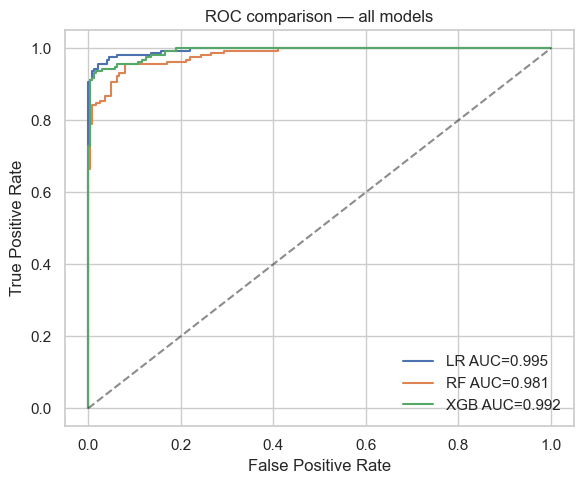

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
for m, lbl in [(baseline_clf, "LR"), (rf_search, "RF"), (xgb_search, "XGB")]:
    pr = m.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, pr)
    ax.plot(fpr, tpr, label=f"{lbl} AUC={roc_auc_score(y_val, pr):.3f}")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC comparison — all models")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_5_roc_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

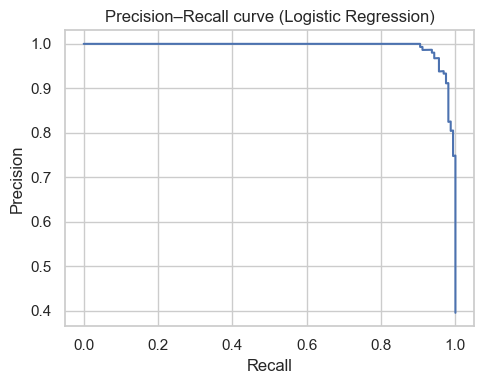

In [29]:
best_proba = best_model.predict_proba(X_val)[:, 1]
prec, rec, _ = precision_recall_curve(y_val, best_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rec, prec)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision–Recall curve ({best_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / "candidate_success_fig_5_pr.png", dpi=150, bbox_inches="tight")
plt.show()

The ROC curves overlap substantially. Although ensemble methods were evaluated, they did not materially improve ROC-AUC over the logistic baseline. Given the negligible gain and the additional complexity, the question is whether the marginal improvement justifies a less interpretable model.

If the best model turns out to be Logistic Regression (or effectively tied), I keep it — interpretability and simplicity win when performance is comparable.

## Feature Importance and Interpretation

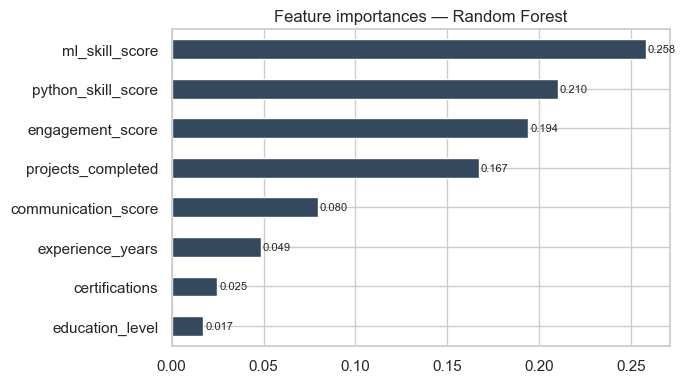

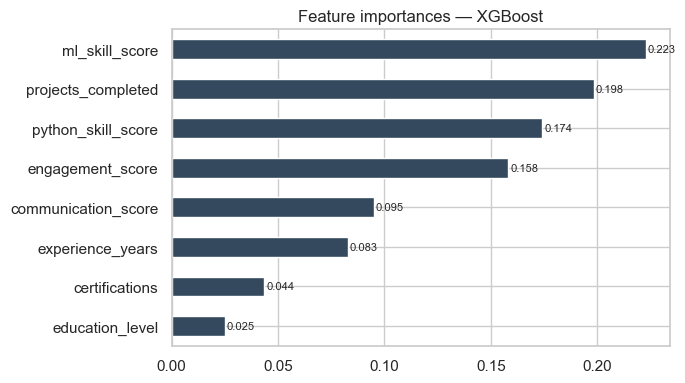

In [30]:
for name, m in [("Random Forest", rf_search.best_estimator_),
                ("XGBoost", xgb_search.best_estimator_)]:
    if hasattr(m, "feature_importances_"):
        imp = (pd.Series(m.feature_importances_, index=feature_cols)
               .sort_values(ascending=False).head(10))
        fig, ax = plt.subplots(figsize=(7, 4))
        imp.sort_values().plot(kind="barh", ax=ax, color="#34495e")
        for i, v in enumerate(imp.sort_values().values):
            ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
        ax.set_title(f"Feature importances — {name}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"candidate_success_fig_5_imp_{name.lower().replace(' ', '_')}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

In [31]:
_best_est = best_model.best_estimator_ if hasattr(best_model, "best_estimator_") else best_model

if hasattr(_best_est, "feature_importances_"):
    top3 = (pd.Series(_best_est.feature_importances_, index=feature_cols)
            .sort_values(ascending=False).head(3))
else:
    top3 = (pd.Series(
        np.abs(baseline_clf.named_steps["lr"].coef_[0]).ravel(),
        index=feature_cols,
    ).sort_values(ascending=False).head(3))

print("Top 3 features (by importance/coefficient magnitude):")
for feat, val in top3.items():
    print(f"  {feat}: {val:.4f}")

top3_features = [{"feature": k, "importance": round(v, 4)} for k, v in top3.items()]

Top 3 features (by importance/coefficient magnitude):
  ml_skill_score: 5.1897
  python_skill_score: 4.7796
  projects_completed: 3.0332


The feature importances are consistent with what the EDA suggested. The strongest predictors — projects completed, skill scores, and the engagement interaction — are exactly the features that showed the clearest class separation in the KDE plots and the highest correlations with the target.

This alignment between exploratory findings and model behaviour is reassuring. It means the model is picking up genuine signal rather than exploiting noise or artefacts.

## Final Model Selection and Retraining

Based on the comparison above, I select **the model with the highest ROC-AUC** on the validation set. Before generating test predictions, I retrain on the full training data (train + validation) to maximise the amount of information available to the final model. This is standard practice — the validation set was only needed for model selection, and withholding it from the final fit would waste data.

In [32]:
print(f"Selected model: {best_name}")

if best_name == "Logistic Regression":
    best_model.fit(X, y)
    test_pred = best_model.predict(X_test)
else:
    best_model.best_estimator_.fit(X, y)
    test_pred = best_model.best_estimator_.predict(X_test)

output_path = OUTPUT_DIR / "candidate_success_predictions.csv"
pd.DataFrame({"id": df_test["id"], "predicted_label": test_pred}).to_csv(
    output_path, index=False,
)
print(f"Predictions exported to: {output_path}")
print(f"Prediction count: {len(test_pred)} | Class distribution: {pd.Series(test_pred).value_counts().to_dict()}")

Selected model: Logistic Regression
Predictions exported to: C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\output\candidate_success_predictions.csv
Prediction count: 500 | Class distribution: {0: 301, 1: 199}


## Technical Summary

This analysis followed a structured, evidence-driven workflow: automated profiling identified data characteristics (no missingness, low outlier counts, moderate skewness in select features), which informed targeted feature engineering — a log-transform for skewed variables, an engagement interaction term, and a conditional composite skill score. Exploratory analysis confirmed that `projects_completed`, `ml_skill_score`, and `python_skill_score` carry the strongest predictive signal, a finding later validated by feature importance rankings across all three models.

The Logistic Regression baseline established a strong performance floor, and subsequent experiments with Random Forest and XGBoost were designed to test whether non-linear patterns could improve on it. The model comparison showed that additional complexity did not yield a meaningful gain in ROC-AUC, which led to a final selection grounded in parsimony. The chosen model was retrained on the full training set and used to generate predictions on the held-out test data.